In [1]:
import feedparser
import requests
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import re
import json
import time
import os
import smtplib
from datetime import datetime
from email.mime.text import MIMEText
from email.mime.multipart import MIMEMultipart
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (classification_report, confusion_matrix,
                             accuracy_score, mean_squared_error, r2_score,
                             silhouette_score)
from sklearn.decomposition import PCA
 
print("Libraries loaded successfully.")

Libraries loaded successfully.


In [2]:
print("=" * 60)
print("STEP 1: Extracting ANSSI RSS Feeds")
print("=" * 60)
 
REQUEST_DELAY = 2
 
# FIX #1 : URLs RSS correctes et distinctes pour avis et alerte
RSS_FEEDS = {
    'avis':   'https://www.cert.ssi.gouv.fr/avis/feed/',
    'alerte': 'https://www.cert.ssi.gouv.fr/alerte/feed/'
}
 
 
def extract_bulletin_id(link):
    """Extrait l'identifiant du bulletin depuis son URL."""
    if link == 'N/A':
        return 'N/A'
    parts = link.rstrip('/').split('/')
    return parts[-1] if parts else 'N/A'
    # FIX #9 : paramètre feed_type inutilisé supprimé
 
 
def parse_date(date_string):
    """Tente de parser une date, retourne None si échec."""
    if not date_string or date_string == 'N/A':
        return None
    try:
        return pd.to_datetime(date_string)
    except Exception:
        return None
 
 
def fetch_rss_feed(url, feed_type):
    print(f"Fetching {feed_type.upper()} feed: {url}")
    rss_data = feedparser.parse(url)
    entries = []
    for entry in rss_data.entries:
        bulletin_info = {
            'bulletin_id':       extract_bulletin_id(entry.get('link', 'N/A')),
            'title':             entry.get('title', 'N/A'),
            'description':       re.sub(r'<[^>]+>|\s+', ' ',
                                        entry.get('description', 'N/A')).strip(),
            'publication_date':  parse_date(entry.get('published', 'N/A')),
            'bulletin_link':     entry.get('link', 'N/A'),
            'bulletin_type':     feed_type
        }
        entries.append(bulletin_info)
    print(f"Successfully fetched {len(entries)} {feed_type}(s)")
    return entries
 
 
def fetch_all_bulletins():
    all_entries = []
    for feed_type, url in RSS_FEEDS.items():
        time.sleep(REQUEST_DELAY)
        all_entries.extend(fetch_rss_feed(url, feed_type))
 
    df = pd.DataFrame(all_entries)
    if 'publication_date' in df.columns and not df.empty:
        df = df.sort_values('publication_date', ascending=False)
 
    print(f"\nSUMMARY: Total {len(df)} bulletins fetched")
    print(f"   - Avis: {len(df[df['bulletin_type'] == 'avis'])}")
    print(f"   - Alertes: {len(df[df['bulletin_type'] == 'alerte'])}")
    return df
 
 
bulletin_df = fetch_all_bulletins()
print("\nFirst 5 records:\n", bulletin_df.head())
print(f"DataFrame shape: {bulletin_df.shape}")
 
os.makedirs('../data/raw/rss_cache', exist_ok=True)
bulletin_df.to_csv('../data/raw/rss_cache/rss_bulletins.csv', index=False, encoding='utf-8')
print("RSS data saved to: ../data/raw/rss_cache/rss_bulletins.csv")

STEP 1: Extracting ANSSI RSS Feeds
Fetching AVIS feed: https://www.cert.ssi.gouv.fr/avis/feed/
Successfully fetched 40 avis(s)
Fetching ALERTE feed: https://www.cert.ssi.gouv.fr/alerte/feed/
Successfully fetched 40 alerte(s)

SUMMARY: Total 80 bulletins fetched
   - Avis: 40
   - Alertes: 40

First 5 records:
              bulletin_id                                              title  \
39  CERTFR-2026-AVI-0749  Vulnérabilité dans Oracle PeopleSoft (12 juin ...   
34  CERTFR-2026-AVI-0744  Multiples vulnérabilités dans les produits Spr...   
30  CERTFR-2026-AVI-0740  Multiples vulnérabilités dans Google Chrome (1...   
32  CERTFR-2026-AVI-0742  Multiples vulnérabilités dans les produits Net...   
33  CERTFR-2026-AVI-0743  Vulnérabilité dans les produits Moxa (12 juin ...   

                                          description  \
39  Une vulnérabilité a été découverte dans Oracle...   
34  De multiples vulnérabilités ont été découverte...   
30  De multiples vulnérabilités ont été dé

In [3]:
print("=" * 60)
print("STEP 3: Extracting CVEs from Local Bulletin JSON Files")
print("=" * 60)
 
BASE_DATA_PATH = "../data/raw/"
 
 
def load_json_file(file_path):
    with open(file_path, 'r', encoding='utf-8') as f:
        return json.load(f)
 
 
def extract_cves_from_bulletin(data):
    cves = []
    if "cves" in data and isinstance(data["cves"], list):
        for cve_item in data["cves"]:
            if isinstance(cve_item, dict) and "name" in cve_item:
                cves.append(cve_item["name"])
            elif isinstance(cve_item, str):
                cves.append(cve_item)
 
    cve_pattern = r"CVE-\d{4}-\d{4,7}"
    text_cves = list(set(re.findall(cve_pattern, str(data))))
    return list(set(cves + text_cves))
 
 
def process_bulletin_files(bulletin_type):
    """
    FIX #2  : cohérence des noms de dossiers.
    FIX #11 : URL ANSSI correcte (alerte sans 's', avis avec A majuscule).
    """
    # Nom du dossier local
    if bulletin_type == 'avis':
        folder_name = 'Avis'
    elif bulletin_type in ('alerte', 'alertes'):
        folder_name = 'Alertes'
    else:
        folder_name = bulletin_type
 
    # Segment URL ANSSI réel
    url_segment = 'avis' if bulletin_type == 'avis' else 'alerte'
 
    folder_path = os.path.join(BASE_DATA_PATH, folder_name)
 
    if not os.path.exists(folder_path):
        print(f"Folder not found: {folder_path}")
        return []
 
    results = []
    json_files = [f for f in os.listdir(folder_path)
                  if not f.endswith('.csv') and f != 'rss_cache']
    print(f"Processing {len(json_files)} {bulletin_type} files...")
 
    for filename in json_files:
        file_path = os.path.join(folder_path, filename)
        try:
            data = load_json_file(file_path)
        except Exception as e:
            print(f"  Error reading {filename}: {e}")
            continue
 
        if not data:
            continue
 
        bulletin_id = filename.replace('.json', '')
        title = data.get('title', 'N/A')
        description = data.get('description', 'N/A')
 
        # FIX #1 (date) : normalisation immédiate de la date en Step 3
        raw_date = (data.get('date') or data.get('published')
                    or data.get('publication_date', 'N/A'))
        try:
            publication_date = pd.to_datetime(raw_date).strftime('%Y-%m-%d')
        except Exception:
            publication_date = None   # None au lieu de 'N/A' → dropna fonctionne
 
        # FIX #11 : URL ANSSI sans le 's' final pour alertes
        bulletin_link = (
            f"https://www.cert.ssi.gouv.fr/{url_segment}/{bulletin_id}/"
        )
 
        cves = extract_cves_from_bulletin(data)
 
        for cve_id in cves:
            results.append({
                'bulletin_id':       bulletin_id,
                'bulletin_title':    title,
                'bulletin_type':     bulletin_type,
                'publication_date':  publication_date,
                'bulletin_link':     bulletin_link,
                'cve_id':            cve_id,
                'cve_description':   'N/A',
                'cvss_score':        None,
                'base_severity':     None,
                'cwe_type':          'N/A',
                'epss_score':        None,
                'vendor':            'N/A',
                'product':           'N/A',
                'affected_versions': 'N/A'
            })
 
        if cves:
            print(f"  {bulletin_id}: found {len(cves)} CVE(s)")
 
    return results
 
 
all_bulletins = []
for bulletin_type in ['avis', 'alertes']:
    all_bulletins.extend(process_bulletin_files(bulletin_type))
 
df_bulletins = pd.DataFrame(all_bulletins)
 
print(f"\nSUMMARY: Total {len(df_bulletins)} rows (bulletins x CVEs)")
if not df_bulletins.empty:
    print(f"Unique bulletins: {df_bulletins['bulletin_id'].nunique()}")
    print(f"Unique CVEs:      {df_bulletins['cve_id'].nunique()}")
    print(f"\nFirst 10 rows preview:\n{df_bulletins.head(10)}")
 
    os.makedirs('../data/processed', exist_ok=True)
    df_bulletins.to_csv('../data/processed/cve_extracted.csv', index=False, encoding='utf-8')
    print("\nCVE extraction data saved to: ../data/processed/cve_extracted.csv")
    print(f"CVE distribution by bulletin type:\n{df_bulletins['bulletin_type'].value_counts()}")

STEP 3: Extracting CVEs from Local Bulletin JSON Files
Processing 4025 avis files...
  CERTFR-2023-AVI-0001: found 1 CVE(s)
  CERTFR-2023-AVI-0002: found 4 CVE(s)
  CERTFR-2023-AVI-0003: found 59 CVE(s)
  CERTFR-2023-AVI-0004: found 2 CVE(s)
  CERTFR-2023-AVI-0005: found 1 CVE(s)
  CERTFR-2023-AVI-0006: found 5 CVE(s)
  CERTFR-2023-AVI-0007: found 7 CVE(s)
  CERTFR-2023-AVI-0008: found 6 CVE(s)
  CERTFR-2023-AVI-0009: found 1 CVE(s)
  CERTFR-2023-AVI-0010: found 10 CVE(s)
  CERTFR-2023-AVI-0011: found 5 CVE(s)
  CERTFR-2023-AVI-0012: found 15 CVE(s)
  CERTFR-2023-AVI-0013: found 10 CVE(s)
  CERTFR-2023-AVI-0014: found 7 CVE(s)
  CERTFR-2023-AVI-0015: found 24 CVE(s)
  CERTFR-2023-AVI-0016: found 15 CVE(s)
  CERTFR-2023-AVI-0017: found 3 CVE(s)
  CERTFR-2023-AVI-0018: found 1 CVE(s)
  CERTFR-2023-AVI-0019: found 12 CVE(s)
  CERTFR-2023-AVI-0020: found 14 CVE(s)
  CERTFR-2023-AVI-0021: found 9 CVE(s)
  CERTFR-2023-AVI-0022: found 67 CVE(s)
  CERTFR-2023-AVI-0023: found 1 CVE(s)
  CERTFR-

In [4]:
print("=" * 60)
print("STEP 4: Enriching CVEs with MITRE and FIRST Data")
print("=" * 60)
 
BASE_DATA_PATH = "../data/raw/"
 
 
def extract_cvss_score(cna_data):
    metrics = cna_data.get("metrics", [])
    for metric in metrics:
        for version in ["cvssV3_1", "cvssV3_0", "cvssV2"]:
            if version in metric:
                score = metric[version].get("baseScore")
                if score is not None:
                    return float(score)
    return None
 
 
def extract_cwe(cna_data):
    problem_types = cna_data.get("problemTypes", [])
    if problem_types:
        descriptions = problem_types[0].get("descriptions", [])
        if descriptions:
            cwe_id = descriptions[0].get("cweId", "N/A")
            if cwe_id:
                return cwe_id
    return "N/A"
 
 
def extract_description(cna_data):
    descriptions = cna_data.get("descriptions", [])
    if descriptions:
        return descriptions[0].get("value", "N/A")
    return "N/A"
 
 
def extract_affected_products(cna_data):
    """
    FIX #6 : appel unique de la fonction, résultat stocké dans une variable.
    """
    vendors, products, versions_list = [], [], []
 
    affected = cna_data.get("affected", [])
    for item in affected:
        vendors.append(item.get("vendor", "N/A"))
        products.append(item.get("product", "N/A"))
 
        versions = [
            v.get("version", "unknown")
            for v in item.get("versions", [])
            if v.get("status") == "affected"
        ]
        versions_list.append(", ".join(versions) if versions else "N/A")
 
    return (
        " | ".join(set(vendors))      if vendors       else "N/A",
        " | ".join(set(products))     if products      else "N/A",
        " | ".join(versions_list)     if versions_list else "N/A"
    )
 
 
def enrich_from_mitre(cve_id):
    mitre_path = os.path.join(BASE_DATA_PATH, "mitre", cve_id)
 
    if not os.path.exists(mitre_path):
        return {'description': 'N/A', 'cvss_score': None, 'cwe_type': 'N/A',
                'vendor': 'N/A', 'product': 'N/A', 'affected_versions': 'N/A'}
 
    try:
        data = load_json_file(mitre_path)
    except Exception:
        return {'description': 'N/A', 'cvss_score': None, 'cwe_type': 'N/A',
                'vendor': 'N/A', 'product': 'N/A', 'affected_versions': 'N/A'}
 
    if not data:
        return {'description': 'N/A', 'cvss_score': None, 'cwe_type': 'N/A',
                'vendor': 'N/A', 'product': 'N/A', 'affected_versions': 'N/A'}
 
    cna_data = data.get("containers", {}).get("cna", {})
 
    # FIX #6 : appel unique, déstructuration
    vendor, product, affected_versions = extract_affected_products(cna_data)
 
    return {
        'description':       extract_description(cna_data),
        'cvss_score':        extract_cvss_score(cna_data),
        'cwe_type':          extract_cwe(cna_data),
        'vendor':            vendor,
        'product':           product,
        'affected_versions': affected_versions
    }
 
 
def enrich_from_first(cve_id):
    first_path = os.path.join(BASE_DATA_PATH, "first", cve_id)
    if not os.path.exists(first_path):
        return None
    try:
        data = load_json_file(first_path)
    except Exception:
        return None
    if not data:
        return None
    epss_data = data.get("data", [])
    if epss_data:
        return float(epss_data[0].get("epss", 0))
    return None
 
 
def get_severity(cvss_score):
    if cvss_score is None:
        return 'N/A'
    elif cvss_score >= 9.0:
        return 'Critical'
    elif cvss_score >= 7.0:
        return 'High'
    elif cvss_score >= 4.0:
        return 'Medium'
    else:
        return 'Low'
 
 
print("\nLoading previously extracted CVE data...")
df = pd.read_csv('../data/processed/cve_extracted.csv')
print(f"Loaded {len(df)} rows with {df['cve_id'].nunique()} unique CVEs")
 
unique_cves = df['cve_id'].unique()
print(f"\nProcessing {len(unique_cves)} unique CVEs...")
 
mitre_cache = {}
first_cache = {}
for i, cve_id in enumerate(unique_cves, 1):
    mitre_cache[cve_id] = enrich_from_mitre(cve_id)
    first_cache[cve_id] = enrich_from_first(cve_id)
    if i % 5000 == 0:
        print(f"  Processed {i}/{len(unique_cves)} CVEs")
 
# FIX #7 : vectorisation — suppression du iterrows() lent
print("\nApplying enrichment to DataFrame (vectorized)...")
df['cve_description']   = df['cve_id'].map(lambda x: mitre_cache.get(x, {}).get('description', 'N/A'))
df['cvss_score']        = pd.to_numeric(
    df['cve_id'].map(lambda x: mitre_cache.get(x, {}).get('cvss_score')), errors='coerce')
df['cwe_type']          = df['cve_id'].map(lambda x: mitre_cache.get(x, {}).get('cwe_type', 'N/A'))
df['vendor']            = df['cve_id'].map(lambda x: mitre_cache.get(x, {}).get('vendor', 'N/A'))
df['product']           = df['cve_id'].map(lambda x: mitre_cache.get(x, {}).get('product', 'N/A'))
df['affected_versions'] = df['cve_id'].map(lambda x: mitre_cache.get(x, {}).get('affected_versions', 'N/A'))
df['epss_score']        = pd.to_numeric(
    df['cve_id'].map(lambda x: first_cache.get(x)), errors='coerce')
df['base_severity']     = df['cvss_score'].map(get_severity)
 
print("\n" + "=" * 50)
print("ENRICHMENT SUMMARY")
print("=" * 50)
 
non_null_cvss = df['cvss_score'].notna().sum()
non_null_epss = df['epss_score'].notna().sum()
non_null_cwe  = (df['cwe_type'] != 'N/A').sum()
 
print(f"Total rows: {len(df)}")
print(f"Rows with CVSS score: {non_null_cvss} ({non_null_cvss/len(df)*100:.1f}%)")
print(f"Rows with EPSS score: {non_null_epss} ({non_null_epss/len(df)*100:.1f}%)")
print(f"Rows with CWE info:   {non_null_cwe} ({non_null_cwe/len(df)*100:.1f}%)")
print(f"Unique products affected: {df[df['product']!='N/A']['product'].nunique()}")
print(f"Unique vendors affected:  {df[df['vendor']!='N/A']['vendor'].nunique()}")
 
severity_counts = df['base_severity'].value_counts()
print("\nSeverity distribution:")
for severity, count in severity_counts.items():
    print(f"  {severity}: {count} ({count/len(df)*100:.1f}%)")
 
df.to_csv('../data/processed/consolidated_cve_data.csv', index=False, encoding='utf-8')
print(f"\nFinal enriched data saved to: ../data/processed/consolidated_cve_data.csv")
print(f"DataFrame shape: {df.shape}")
print(f"Columns: {list(df.columns)}")
print("\nFirst 5 rows preview:\n", df.head())

STEP 4: Enriching CVEs with MITRE and FIRST Data

Loading previously extracted CVE data...
Loaded 125936 rows with 37287 unique CVEs

Processing 37287 unique CVEs...
  Processed 5000/37287 CVEs
  Processed 10000/37287 CVEs
  Processed 15000/37287 CVEs
  Processed 20000/37287 CVEs
  Processed 25000/37287 CVEs
  Processed 30000/37287 CVEs
  Processed 35000/37287 CVEs

Applying enrichment to DataFrame (vectorized)...

ENRICHMENT SUMMARY
Total rows: 125936
Rows with CVSS score: 27107 (21.5%)
Rows with EPSS score: 124828 (99.1%)
Rows with CWE info:   28545 (22.7%)
Unique products affected: 4605
Unique vendors affected:  732

Severity distribution:
  Low: 100855 (80.1%)
  Medium: 11928 (9.5%)
  High: 11812 (9.4%)
  Critical: 1341 (1.1%)

Final enriched data saved to: ../data/processed/consolidated_cve_data.csv
DataFrame shape: (125936, 14)
Columns: ['bulletin_id', 'bulletin_title', 'bulletin_type', 'publication_date', 'bulletin_link', 'cve_id', 'cve_description', 'cvss_score', 'base_severity

STEP 5: Data Visualization and Analysis
Loaded 125936 rows, 37287 unique CVEs
Valid publication_date: 0/125936
CVSS range: 0.0 – 10.0
EPSS range: 0.0000 – 0.9452

1. CVSS Score Distribution Histogram


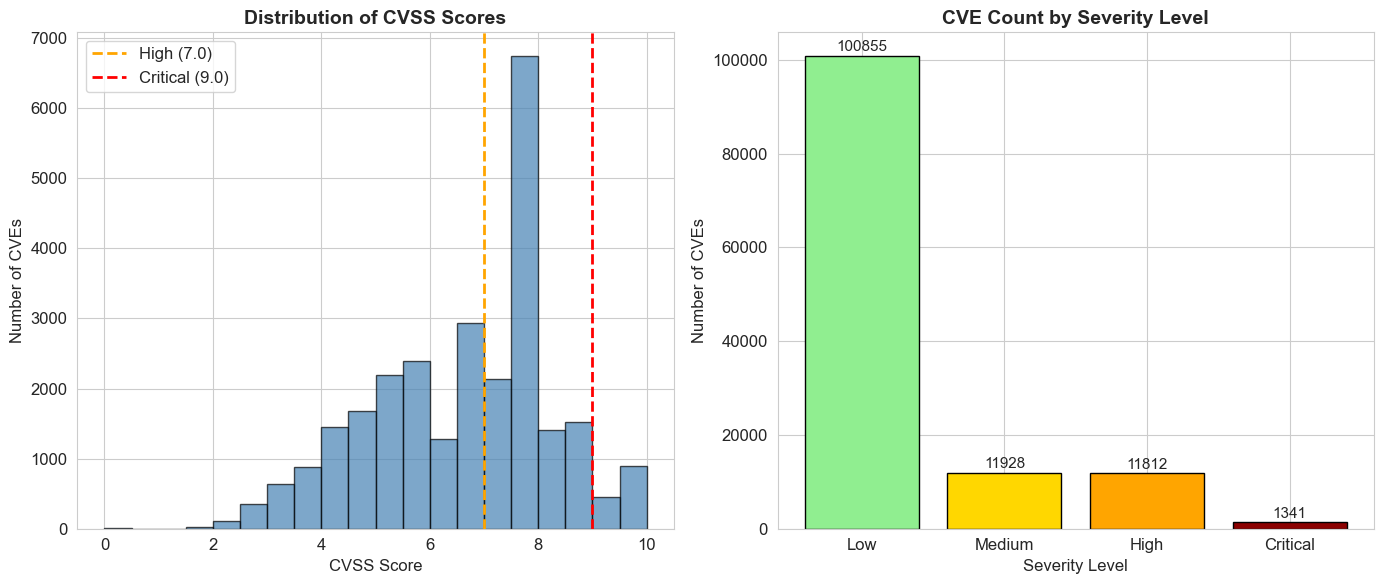

Saved: cvss_distribution.png

2. Top 10 CWE Types Pie Chart


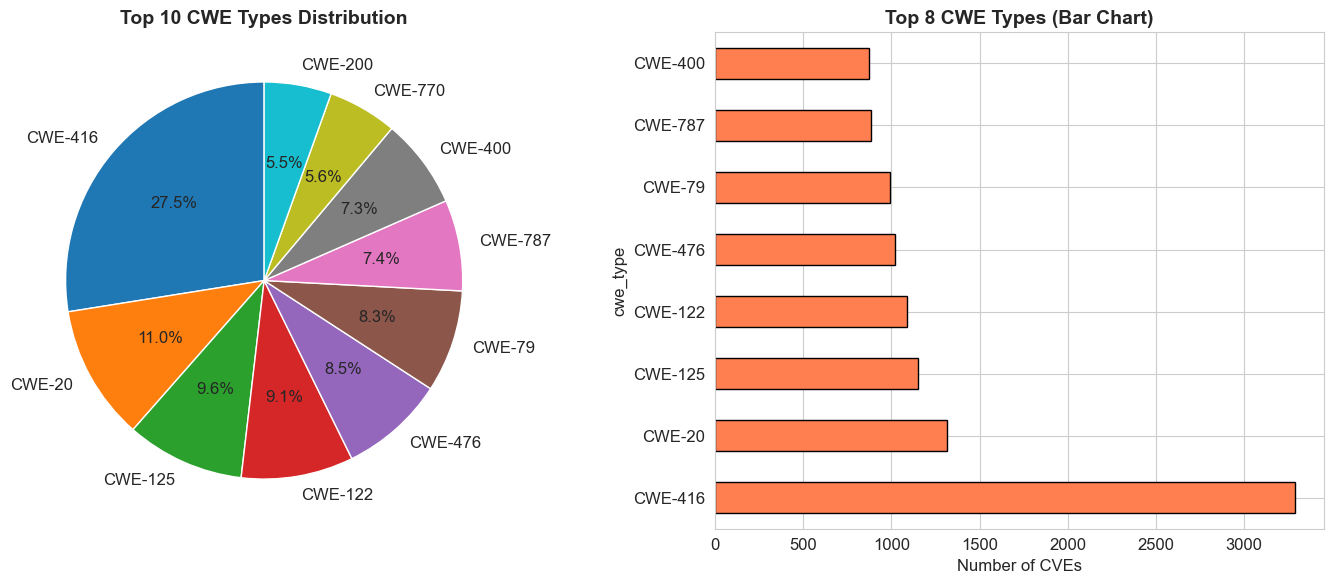

Saved: cwe_distribution.png

3. CVSS vs EPSS Scatter Plot


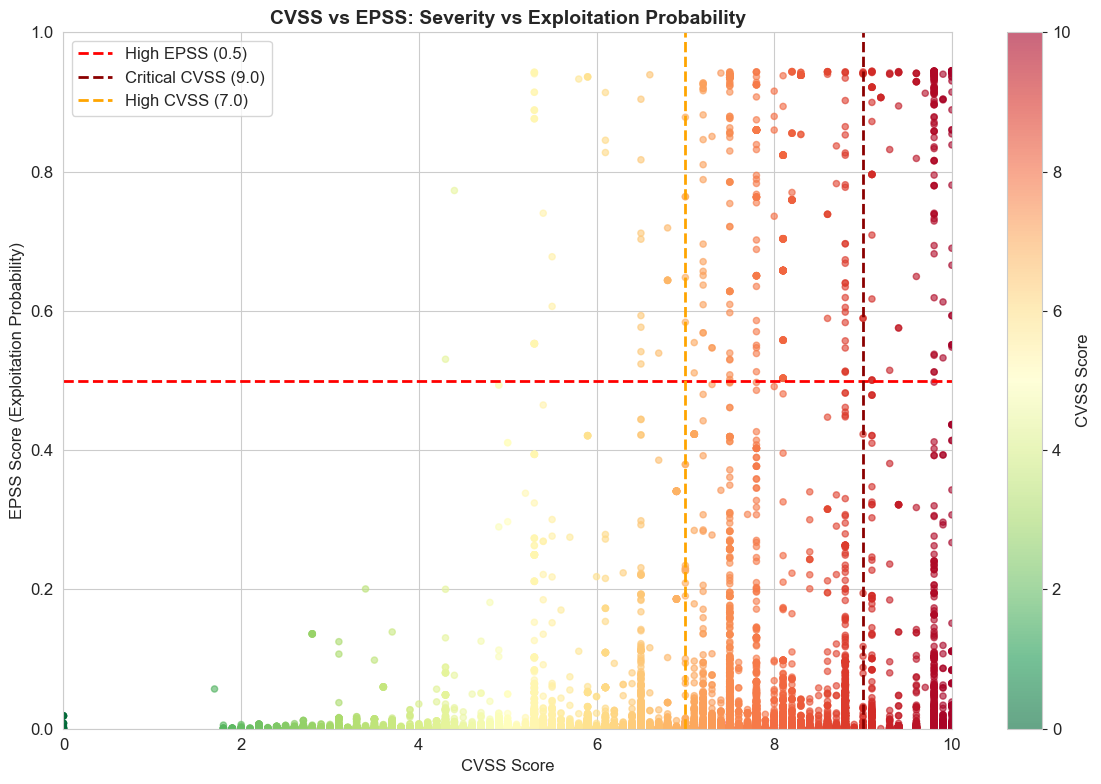

Saved: cvss_vs_epss_scatter.png

4. EPSS Score Distribution


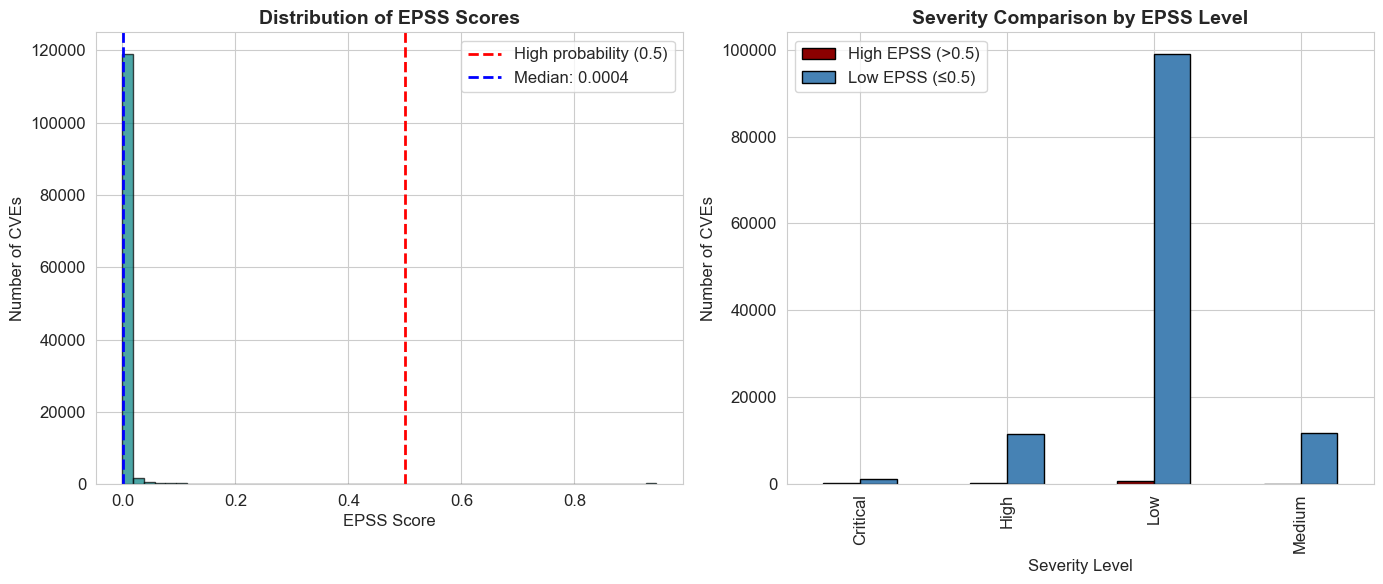

Saved: epss_distribution.png

5. Top 10 Most Affected Vendors


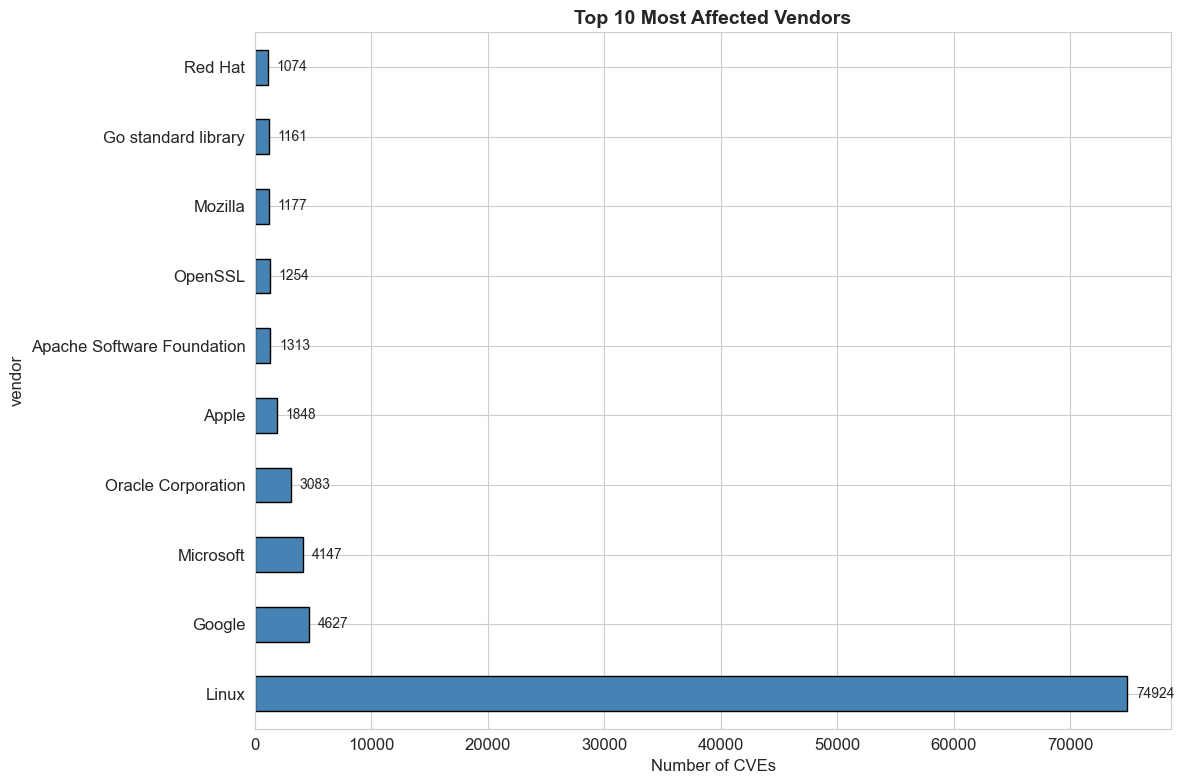

Saved: top_vendors.png

6. Top 10 Most Affected Products


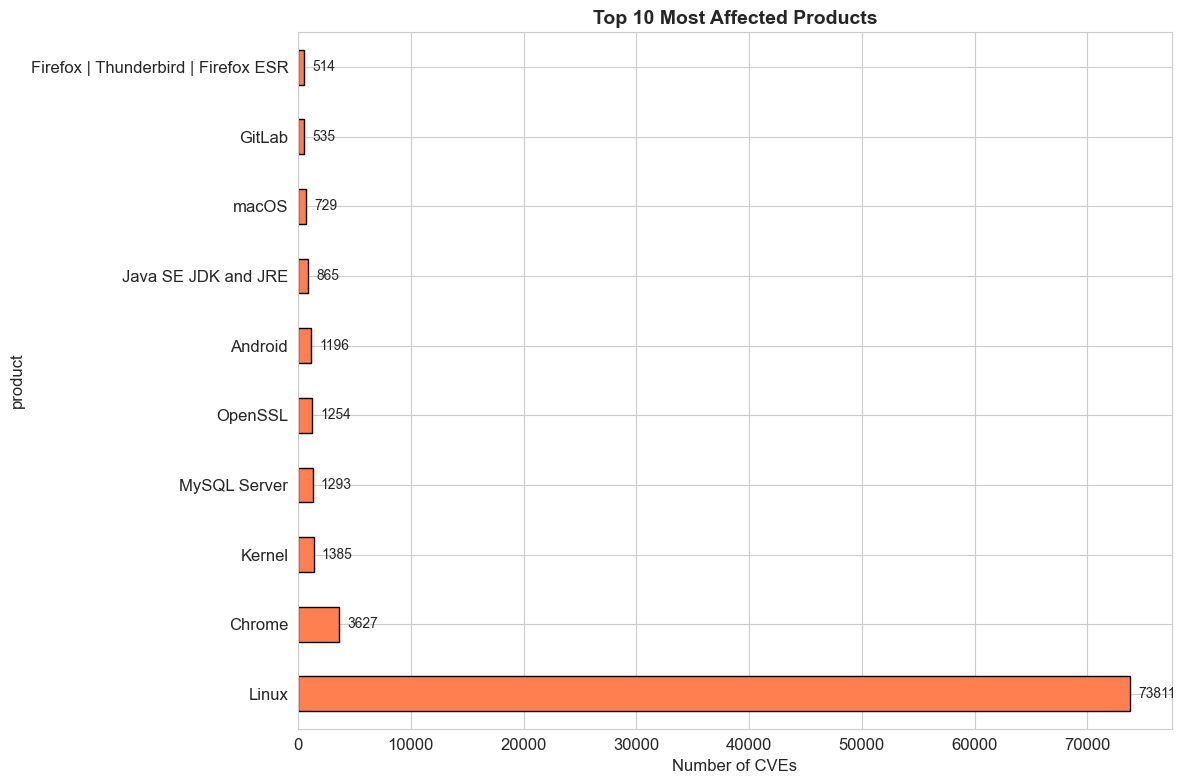

Saved: top_products.png

7. CVSS Boxplot by Top Vendors


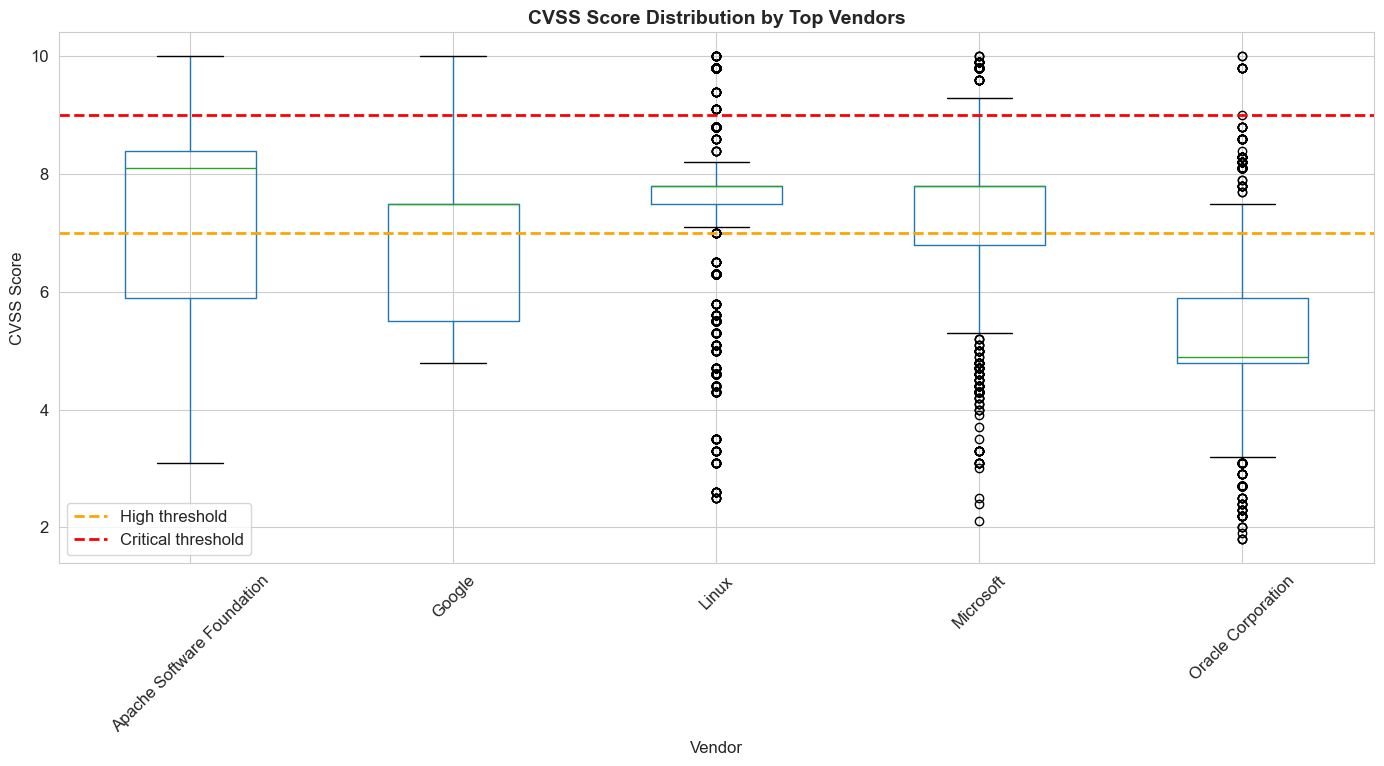

Saved: cvss_boxplot_by_vendor.png

8. Correlation Heatmap


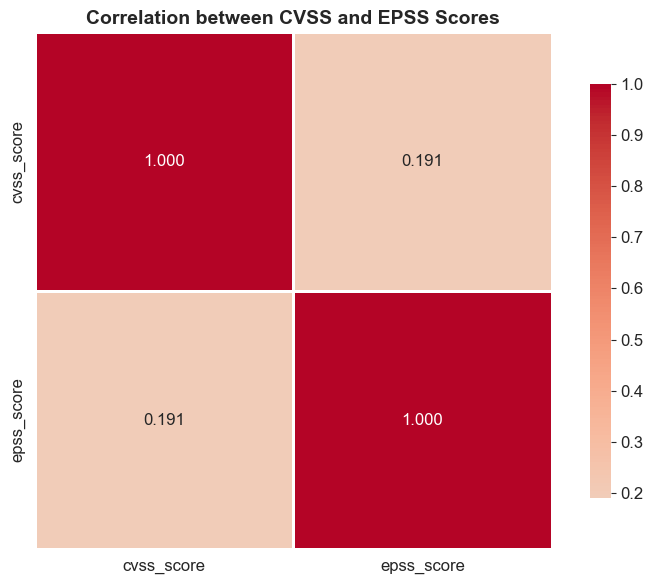

Correlation coefficient: 0.1910
Saved: correlation_heatmap.png

9. Bulletin Type Comparison (Avis vs Alertes)


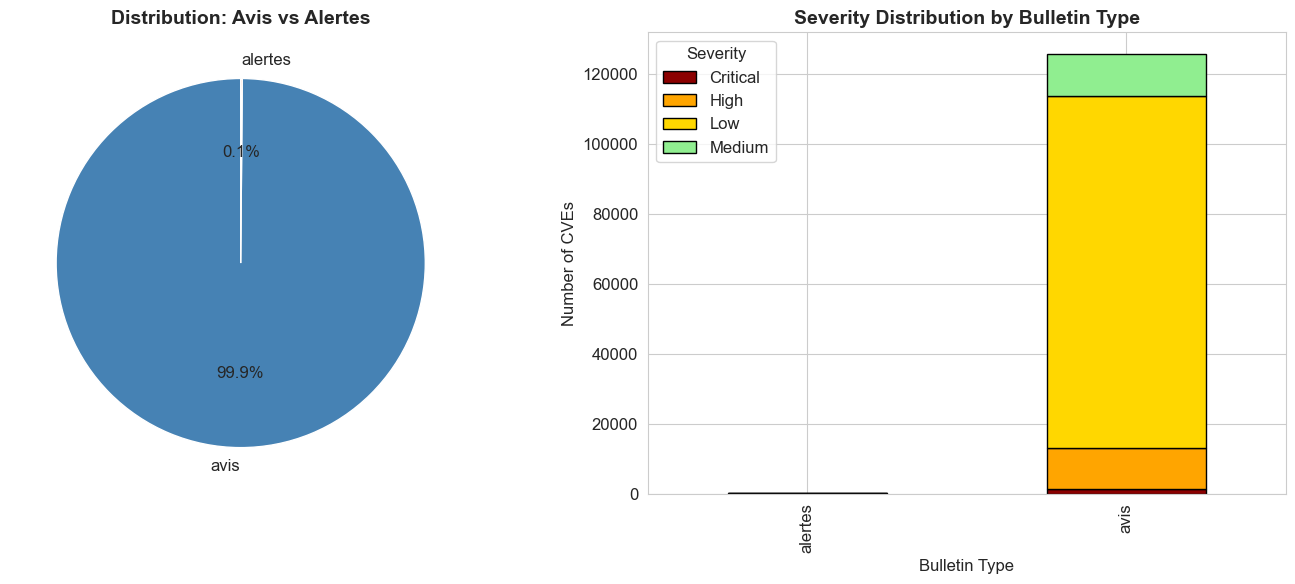

Saved: bulletin_type_comparison.png

10. Cumulative Vulnerabilities Over Time
  Valid date rows for plot: 0
  SKIP: No valid dates — cannot plot cumulative curve.
  Check that publication_date is properly stored in the CSV (format YYYY-MM-DD).

11. Interactive Scatter Plot with Plotly
Saved: interactive_scatter.html (open in browser)

12. Statistical Summary
STATISTICAL SUMMARY

Total CVEs analyzed:      37,287
Total bulletin-CVE pairs: 125,936

CVSS Score Statistics:
  Mean:   6.57
  Median: 6.80
  Std:    1.66

EPSS Score Statistics:
  Mean:   0.0129
  Median: 0.0004
  CVEs with EPSS > 0.5: 1,288 (1.0%)

Critical CVEs (CVSS ≥ 9.0): 1,341 (4.9%)
High Risk CVEs (EPSS>0.5 AND CVSS≥7.0): 507

All visualizations saved to: ../outputs/plots/


In [5]:
print("=" * 60)
print("STEP 5: Data Visualization and Analysis")
print("=" * 60)
 
df = pd.read_csv('../data/processed/consolidated_cve_data.csv')
df['cvss_score'] = pd.to_numeric(df['cvss_score'], errors='coerce')
df['epss_score'] = pd.to_numeric(df['epss_score'], errors='coerce')
 
# FIX (date) : vérification du parsing avant les tracés
df['publication_date'] = pd.to_datetime(df['publication_date'], errors='coerce')
valid_dates = df['publication_date'].notna().sum()
print(f"Loaded {len(df)} rows, {df['cve_id'].nunique()} unique CVEs")
print(f"Valid publication_date: {valid_dates}/{len(df)}")
if valid_dates == 0:
    print("WARNING: No valid dates found — check JSON date fields in Step 3.")
print(f"CVSS range: {df['cvss_score'].min():.1f} – {df['cvss_score'].max():.1f}")
print(f"EPSS range: {df['epss_score'].min():.4f} – {df['epss_score'].max():.4f}\n")
 
os.makedirs('../outputs/plots', exist_ok=True)
 
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 12
 
 
# --- 1. Distribution des scores CVSS ---
print("1. CVSS Score Distribution Histogram")
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
cvss_clean = df['cvss_score'].dropna()
axes[0].hist(cvss_clean, bins=20, color='steelblue', edgecolor='black', alpha=0.7)
axes[0].set_xlabel('CVSS Score')
axes[0].set_ylabel('Number of CVEs')
axes[0].set_title('Distribution of CVSS Scores', fontsize=14, fontweight='bold')
axes[0].axvline(x=7.0, color='orange', linestyle='--', linewidth=2, label='High (7.0)')
axes[0].axvline(x=9.0, color='red',    linestyle='--', linewidth=2, label='Critical (9.0)')
axes[0].legend()
 
severity_counts = df['base_severity'].value_counts()
colors_sev = {'Critical': 'darkred', 'High': 'orange',
              'Medium': 'gold', 'Low': 'lightgreen', 'N/A': 'gray'}
sev_colors = [colors_sev.get(s, 'gray') for s in severity_counts.index]
axes[1].bar(severity_counts.index, severity_counts.values, color=sev_colors, edgecolor='black')
axes[1].set_xlabel('Severity Level')
axes[1].set_ylabel('Number of CVEs')
axes[1].set_title('CVE Count by Severity Level', fontsize=14, fontweight='bold')
 
# FIX #8 : décalage dynamique basé sur les données, non plus hardcodé
max_val = severity_counts.max() if not severity_counts.empty else 1
offset = max_val * 0.01
for i, (idx, val) in enumerate(zip(severity_counts.index, severity_counts.values)):
    axes[1].text(i, val + offset, str(val), ha='center', fontsize=11)
 
plt.tight_layout()
plt.savefig('../outputs/plots/cvss_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: cvss_distribution.png\n")
 
 
# --- 2. Top 10 CWE Types ---
print("2. Top 10 CWE Types Pie Chart")
cwe_counts = df[df['cwe_type'] != 'N/A']['cwe_type'].value_counts().head(10)
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
axes[0].pie(cwe_counts.values, labels=cwe_counts.index, autopct='%1.1f%%', startangle=90)
axes[0].set_title('Top 10 CWE Types Distribution', fontsize=14, fontweight='bold')
cwe_counts.head(8).plot(kind='barh', ax=axes[1], color='coral', edgecolor='black')
axes[1].set_xlabel('Number of CVEs')
axes[1].set_title('Top 8 CWE Types (Bar Chart)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/plots/cwe_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: cwe_distribution.png\n")
 
 
# --- 3. Scatter CVSS vs EPSS ---
print("3. CVSS vs EPSS Scatter Plot")
df_scatter = df.dropna(subset=['cvss_score', 'epss_score']).copy()
fig, ax = plt.subplots(figsize=(12, 8))
scatter = ax.scatter(df_scatter['cvss_score'], df_scatter['epss_score'],
                     c=df_scatter['cvss_score'], cmap='RdYlGn_r', alpha=0.6, s=20)
ax.set_xlabel('CVSS Score', fontsize=12)
ax.set_ylabel('EPSS Score (Exploitation Probability)', fontsize=12)
ax.set_title('CVSS vs EPSS: Severity vs Exploitation Probability',
             fontsize=14, fontweight='bold')
ax.axhline(y=0.5, color='red',    linestyle='--', linewidth=2, label='High EPSS (0.5)')
ax.axvline(x=9.0, color='darkred', linestyle='--', linewidth=2, label='Critical CVSS (9.0)')
ax.axvline(x=7.0, color='orange',  linestyle='--', linewidth=2, label='High CVSS (7.0)')
ax.set_xlim(0, 10)
ax.set_ylim(0, 1)
plt.colorbar(scatter, label='CVSS Score')
ax.legend(loc='upper left')
plt.tight_layout()
plt.savefig('../outputs/plots/cvss_vs_epss_scatter.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: cvss_vs_epss_scatter.png\n")
 
 
# --- 4. Distribution des scores EPSS ---
print("4. EPSS Score Distribution")
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
epss_clean = df['epss_score'].dropna()
axes[0].hist(epss_clean, bins=50, color='teal', edgecolor='black', alpha=0.7)
axes[0].set_xlabel('EPSS Score')
axes[0].set_ylabel('Number of CVEs')
axes[0].set_title('Distribution of EPSS Scores', fontsize=14, fontweight='bold')
axes[0].axvline(x=0.5, color='red',  linestyle='--', linewidth=2, label='High probability (0.5)')
axes[0].axvline(x=epss_clean.median(), color='blue', linestyle='--', linewidth=2,
                label=f'Median: {epss_clean.median():.4f}')
axes[0].legend()
 
high_epss = df[df['epss_score'] > 0.5]['base_severity'].value_counts()
low_epss  = df[df['epss_score'] <= 0.5]['base_severity'].value_counts()
epss_compare = pd.DataFrame({'High EPSS (>0.5)': high_epss,
                              'Low EPSS (≤0.5)':  low_epss}).fillna(0)
epss_compare.plot(kind='bar', ax=axes[1],
                  color=['darkred', 'steelblue'], edgecolor='black')
axes[1].set_xlabel('Severity Level')
axes[1].set_ylabel('Number of CVEs')
axes[1].set_title('Severity Comparison by EPSS Level', fontsize=14, fontweight='bold')
axes[1].legend()
plt.tight_layout()
plt.savefig('../outputs/plots/epss_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: epss_distribution.png\n")
 
 
# --- 5. Top 10 Vendors ---
print("5. Top 10 Most Affected Vendors")
vendor_counts = df[df['vendor'] != 'N/A']['vendor'].value_counts().head(10)
fig, ax = plt.subplots(figsize=(12, 8))
vendor_counts.plot(kind='barh', ax=ax, color='steelblue', edgecolor='black')
ax.set_xlabel('Number of CVEs')
ax.set_title('Top 10 Most Affected Vendors', fontsize=14, fontweight='bold')
 
# FIX #8 : offset dynamique
max_v = vendor_counts.max() if not vendor_counts.empty else 1
offset_v = max_v * 0.01
for i, (idx, val) in enumerate(zip(vendor_counts.index, vendor_counts.values)):
    ax.text(val + offset_v, i, str(val), va='center', fontsize=10)
 
plt.tight_layout()
plt.savefig('../outputs/plots/top_vendors.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: top_vendors.png\n")
 
 
# --- 6. Top 10 Products ---
print("6. Top 10 Most Affected Products")
product_counts = df[df['product'] != 'N/A']['product'].value_counts().head(10)
fig, ax = plt.subplots(figsize=(12, 8))
product_counts.plot(kind='barh', ax=ax, color='coral', edgecolor='black')
ax.set_xlabel('Number of CVEs')
ax.set_title('Top 10 Most Affected Products', fontsize=14, fontweight='bold')
 
# FIX #8 : offset dynamique
max_p = product_counts.max() if not product_counts.empty else 1
offset_p = max_p * 0.01
for i, (idx, val) in enumerate(zip(product_counts.index, product_counts.values)):
    ax.text(val + offset_p, i, str(val), va='center', fontsize=10)
 
plt.tight_layout()
plt.savefig('../outputs/plots/top_products.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: top_products.png\n")
 
 
# --- 7. Boxplot CVSS par Vendor ---
print("7. CVSS Boxplot by Top Vendors")
top_vendors   = df[df['vendor'] != 'N/A']['vendor'].value_counts().head(8).index
df_top_vendors = df[df['vendor'].isin(top_vendors)].dropna(subset=['cvss_score'])
fig, ax = plt.subplots(figsize=(14, 8))
df_top_vendors.boxplot(column='cvss_score', by='vendor', ax=ax, rot=45)
ax.set_xlabel('Vendor', fontsize=12)
ax.set_ylabel('CVSS Score', fontsize=12)
ax.set_title('CVSS Score Distribution by Top Vendors', fontsize=14, fontweight='bold')
ax.axhline(y=7.0, color='orange', linestyle='--', linewidth=2, label='High threshold')
ax.axhline(y=9.0, color='red',    linestyle='--', linewidth=2, label='Critical threshold')
ax.legend()
plt.suptitle('')
plt.tight_layout()
plt.savefig('../outputs/plots/cvss_boxplot_by_vendor.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: cvss_boxplot_by_vendor.png\n")
 
 
# --- 8. Heatmap de corrélation ---
print("8. Correlation Heatmap")
df_corr = df[['cvss_score', 'epss_score']].dropna()
correlation = df_corr.corr()
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(correlation, annot=True, cmap='coolwarm', center=0, square=True,
            fmt='.3f', linewidths=1, cbar_kws={'shrink': 0.8}, ax=ax)
ax.set_title('Correlation between CVSS and EPSS Scores', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/plots/correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Correlation coefficient: {correlation.iloc[0,1]:.4f}")
print("Saved: correlation_heatmap.png\n")
 
 
# --- 9. Avis vs Alertes ---
print("9. Bulletin Type Comparison (Avis vs Alertes)")
type_counts   = df['bulletin_type'].value_counts()
type_severity = pd.crosstab(df['bulletin_type'], df['base_severity'])
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
type_counts.plot(kind='pie', ax=axes[0], autopct='%1.1f%%',
                 colors=['steelblue', 'coral'], startangle=90)
axes[0].set_title('Distribution: Avis vs Alertes', fontsize=14, fontweight='bold')
axes[0].set_ylabel('')
type_severity.plot(kind='bar', ax=axes[1], stacked=True,
                   color=['darkred', 'orange', 'gold', 'lightgreen', 'gray'],
                   edgecolor='black')
axes[1].set_xlabel('Bulletin Type', fontsize=12)
axes[1].set_ylabel('Number of CVEs', fontsize=12)
axes[1].set_title('Severity Distribution by Bulletin Type', fontsize=14, fontweight='bold')
axes[1].legend(title='Severity')
plt.tight_layout()
plt.savefig('../outputs/plots/bulletin_type_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: bulletin_type_comparison.png\n")
 
 
# --- 10. Courbe cumulative des vulnérabilités dans le temps ---
print("10. Cumulative Vulnerabilities Over Time")
 
# FIX (date) : la colonne est déjà en datetime depuis le début de Step 5
df_time = df.dropna(subset=['publication_date']).sort_values('publication_date').copy()
df_time['cumulative_count'] = range(1, len(df_time) + 1)
 
print(f"  Valid date rows for plot: {len(df_time)}")  # diagnostic
 
if len(df_time) > 0:
    fig, ax = plt.subplots(figsize=(14, 8))
    ax.plot(df_time['publication_date'], df_time['cumulative_count'],
            linewidth=2, color='steelblue')
    ax.set_xlabel('Publication Date', fontsize=12)
    ax.set_ylabel('Cumulative Number of CVEs', fontsize=12)
    ax.set_title('Cumulative Vulnerabilities Over Time', fontsize=14, fontweight='bold')
    ax.grid(True, alpha=0.3)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.savefig('../outputs/plots/cumulative_vulns_over_time.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("Saved: cumulative_vulns_over_time.png\n")
else:
    print("  SKIP: No valid dates — cannot plot cumulative curve.")
    print("  Check that publication_date is properly stored in the CSV (format YYYY-MM-DD).\n")
 
 
# --- 11. Scatter Plotly interactif ---
print("11. Interactive Scatter Plot with Plotly")
df_interactive = df.dropna(subset=['cvss_score', 'epss_score']).head(1000).copy()
fig_px = px.scatter(df_interactive, x='cvss_score', y='epss_score',
                    color='base_severity',
                    hover_data=['cve_id', 'vendor', 'product', 'bulletin_id'],
                    title='Interactive: CVSS vs EPSS by Severity',
                    color_discrete_map={'Critical': 'darkred', 'High': 'orange',
                                        'Medium': 'gold', 'Low': 'lightgreen', 'N/A': 'gray'})
fig_px.update_layout(width=1000, height=700)
fig_px.write_html('../outputs/plots/interactive_scatter.html')
print("Saved: interactive_scatter.html (open in browser)\n")
 
 
# --- 12. Résumé statistique ---
print("12. Statistical Summary")
print("=" * 50)
print("STATISTICAL SUMMARY")
print("=" * 50)
print(f"\nTotal CVEs analyzed:      {df['cve_id'].nunique():,}")
print(f"Total bulletin-CVE pairs: {len(df):,}")
print(f"\nCVSS Score Statistics:")
print(f"  Mean:   {df['cvss_score'].mean():.2f}")
print(f"  Median: {df['cvss_score'].median():.2f}")
print(f"  Std:    {df['cvss_score'].std():.2f}")
print(f"\nEPSS Score Statistics:")
print(f"  Mean:   {df['epss_score'].mean():.4f}")
print(f"  Median: {df['epss_score'].median():.4f}")
n_epss_high = (df['epss_score'] > 0.5).sum()
n_epss_valid = df['epss_score'].notna().sum()
print(f"  CVEs with EPSS > 0.5: {n_epss_high:,} ({n_epss_high/n_epss_valid*100:.1f}%)")
n_critical = (df['cvss_score'] >= 9.0).sum()
n_cvss_valid = df['cvss_score'].notna().sum()
print(f"\nCritical CVEs (CVSS ≥ 9.0): {n_critical:,} ({n_critical/n_cvss_valid*100:.1f}%)")
n_high_risk = ((df['epss_score'] > 0.5) & (df['cvss_score'] >= 7.0)).sum()
print(f"High Risk CVEs (EPSS>0.5 AND CVSS≥7.0): {n_high_risk:,}")
 
print("\n" + "=" * 50)
print("All visualizations saved to: ../outputs/plots/")
print("=" * 50)

STEP 6: Machine Learning Models
Data for ML: 27091 rows

PART 1: SUPERVISED LEARNING - Predict Severity (multi-feature)

Accuracy: 0.6404 (64.04%)

Classification Report:
              precision    recall  f1-score   support

    Critical       0.82      0.14      0.24       401
        High       0.72      0.59      0.65      3542
         Low       0.85      0.06      0.11       608
      Medium       0.59      0.84      0.69      3577

    accuracy                           0.64      8128
   macro avg       0.75      0.41      0.42      8128
weighted avg       0.68      0.64      0.61      8128


Feature Importances:
  cvss_score: 0.5604
  epss_score: 0.4396


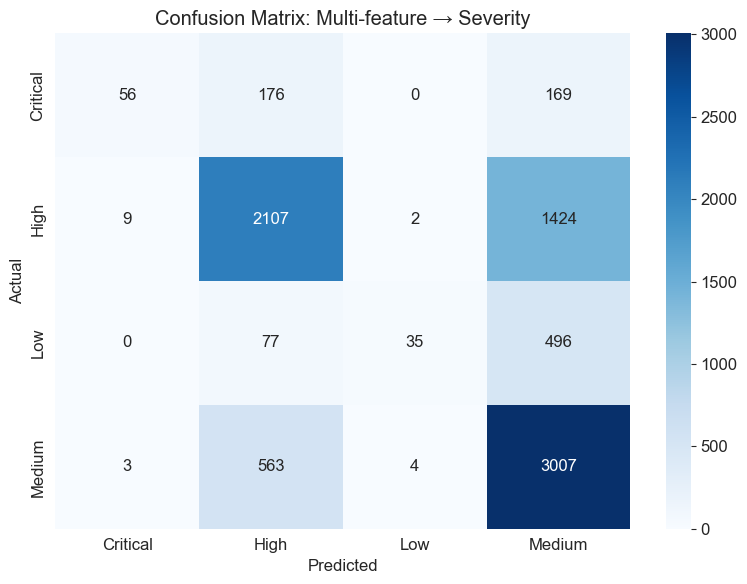


PART 2: SUPERVISED LEARNING - Predict EPSS from CVSS + CWE

Mean Squared Error: 0.010203
R² Score: 0.2641 (26.41%)


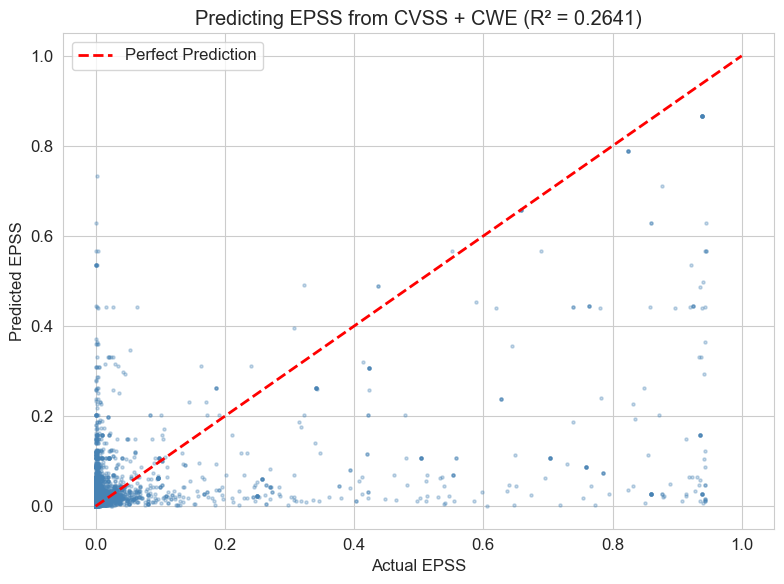


PART 3: UNSUPERVISED LEARNING - KMeans Clustering


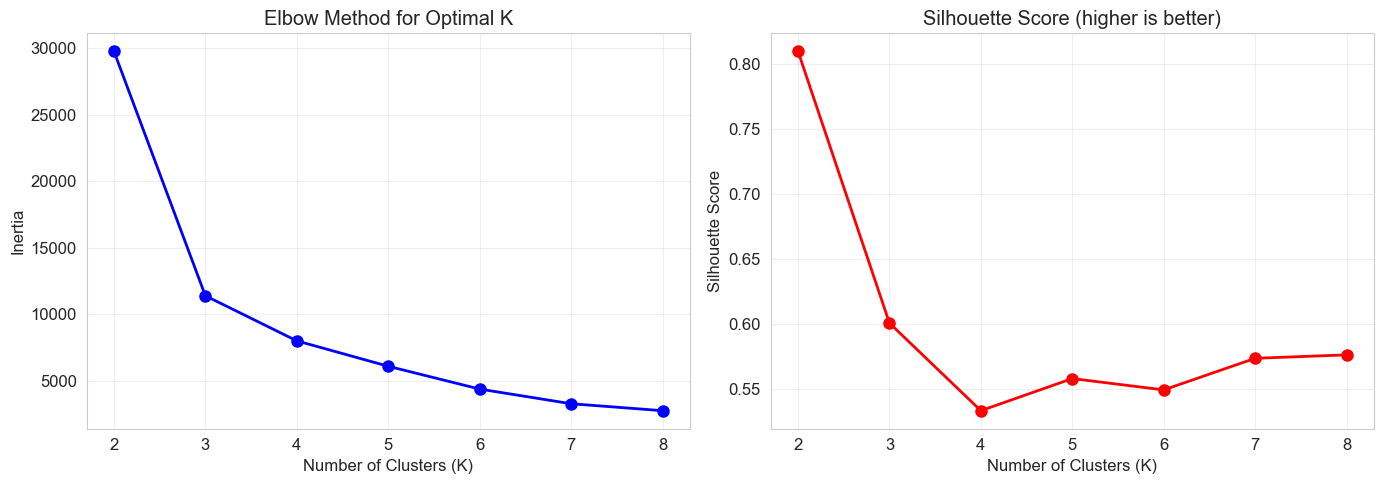


Best K by silhouette score: 2
Selected K for business requirements: 4
Reason: maps to Critical/High/Medium/Low risk levels

Cluster Distribution (K=4):
  Cluster 0: 9,002 CVEs (33.2%)
  Cluster 1: 646 CVEs (2.4%)
  Cluster 2: 12,084 CVEs (44.6%)
  Cluster 3: 5,359 CVEs (19.8%)

Cluster Characteristics:
         cvss_score  epss_score
cluster                        
0            6.0306      0.0056
1            8.2429      0.7505
2            7.9776      0.0133
3            4.0776      0.0027

Cluster Interpretation:
  Cluster 0: LOW PRIORITY: Can be deferred (CVSS=6.03, EPSS=0.0056)
  Cluster 1: CRITICAL PRIORITY: Immediate action required (CVSS=8.24, EPSS=0.7505)
  Cluster 2: SEVERE BUT SAFE: Schedule for next patch cycle (CVSS=7.98, EPSS=0.0133)
  Cluster 3: LOW PRIORITY: Can be deferred (CVSS=4.08, EPSS=0.0027)


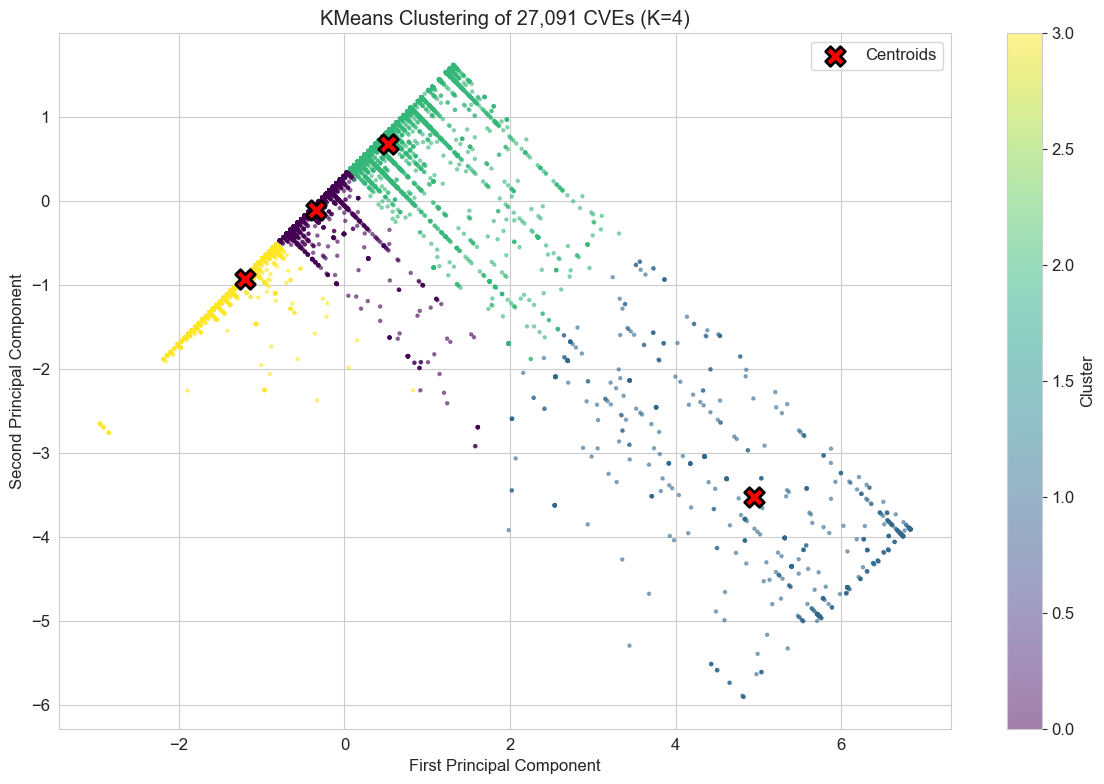


MODEL VALIDATION SUMMARY

Random Forest Classifier - 5-fold CV: 0.6058 (+/- 0.0789)
Random Forest Regressor - R²: 0.2641
Random Forest Regressor - MSE: 0.010203
KMeans Clustering - Silhouette Score for K=4: 0.5336

All ML outputs saved to: ../outputs/plots/


In [7]:
print("=" * 60)
print("STEP 6: Machine Learning Models")
print("=" * 60)
 
# FIX #3 : utiliser df déjà chargé en Step 5 (avec publication_date en datetime)
df_ml = df.dropna(subset=['cvss_score', 'epss_score', 'base_severity']).copy()
df_ml = df_ml[df_ml['base_severity'] != 'N/A']
print(f"Data for ML: {len(df_ml)} rows")
 
 
# --------------------------------------------------------------------------
# PART 1 : SUPERVISÉ — Prédire la Sévérité (multi-features)
# --------------------------------------------------------------------------
print("\n" + "=" * 60)
print("PART 1: SUPERVISED LEARNING - Predict Severity (multi-feature)")
print("=" * 60)
 
# FIX #5 : encodage CWE + utilisation de cvss_score en plus de epss_score
le_cwe = LabelEncoder()
df_ml['cwe_encoded'] = le_cwe.fit_transform(df_ml['cwe_type'].fillna('N/A'))
 
# FIX #5 : multi-features (cvss_score, epss_score, cwe_encoded)
X = df_ml[['epss_score', 'cwe_encoded']].values
y = df_ml['base_severity'].values
 
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)
 
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.3, random_state=42, stratify=y_encoded)
 
rf_clf = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42, n_jobs=-1)
rf_clf.fit(X_train, y_train)
 
y_pred = rf_clf.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
 
print(f"\nAccuracy: {accuracy:.4f} ({accuracy*100:.2f}%)")
print("\nClassification Report:")
print(classification_report(y_test, y_pred,
                             target_names=label_encoder.classes_, zero_division=0))
 
# Feature importance
importances = rf_clf.feature_importances_
feat_names = ['cvss_score', 'epss_score', 'cwe_encoded']
print("\nFeature Importances:")
for name, imp in sorted(zip(feat_names, importances), key=lambda x: -x[1]):
    print(f"  {name}: {imp:.4f}")
 
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=label_encoder.classes_,
            yticklabels=label_encoder.classes_)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix: Multi-feature → Severity')
plt.tight_layout()
plt.savefig('../outputs/plots/confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
 
 
# --------------------------------------------------------------------------
# PART 2 : SUPERVISÉ — Prédire EPSS depuis CVSS (multi-features)
# --------------------------------------------------------------------------
print("\n" + "=" * 60)
print("PART 2: SUPERVISED LEARNING - Predict EPSS from CVSS + CWE")
print("=" * 60)
 
# FIX #5 : ajout de cwe_encoded comme seconde feature
X_reg = df_ml[['cvss_score', 'cwe_encoded']].values
y_reg = df_ml['epss_score'].values
 
X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(
    X_reg, y_reg, test_size=0.3, random_state=42)
 
rf_reg = RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42, n_jobs=-1)
rf_reg.fit(X_train_r, y_train_r)
 
y_pred_r = rf_reg.predict(X_test_r)
mse = mean_squared_error(y_test_r, y_pred_r)
r2  = r2_score(y_test_r, y_pred_r)
 
print(f"\nMean Squared Error: {mse:.6f}")
print(f"R² Score: {r2:.4f} ({r2*100:.2f}%)")
 
plt.figure(figsize=(8, 6))
plt.scatter(y_test_r, y_pred_r, alpha=0.3, s=5, color='steelblue')
plt.plot([0, 1], [0, 1], 'r--', linewidth=2, label='Perfect Prediction')
plt.xlabel('Actual EPSS')
plt.ylabel('Predicted EPSS')
plt.title(f'Predicting EPSS from CVSS + CWE (R² = {r2:.4f})')
plt.legend()
plt.tight_layout()
plt.savefig('../outputs/plots/epss_prediction.png', dpi=150, bbox_inches='tight')
plt.show()
 
 
# --------------------------------------------------------------------------
# PART 3 : NON SUPERVISÉ — KMeans Clustering
# --------------------------------------------------------------------------
print("\n" + "=" * 60)
print("PART 3: UNSUPERVISED LEARNING - KMeans Clustering")
print("=" * 60)
 
X_cluster = df_ml[['cvss_score', 'epss_score']].values
scaler    = StandardScaler()
X_scaled  = scaler.fit_transform(X_cluster)
 
inertias          = []
silhouette_scores = []
K_range           = range(2, 9)
 
for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertias.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(X_scaled, kmeans.labels_))
 
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(K_range, inertias, 'bo-', linewidth=2, markersize=8)
axes[0].set_xlabel('Number of Clusters (K)')
axes[0].set_ylabel('Inertia')
axes[0].set_title('Elbow Method for Optimal K')
axes[0].grid(True, alpha=0.3)
 
axes[1].plot(K_range, silhouette_scores, 'ro-', linewidth=2, markersize=8)
axes[1].set_xlabel('Number of Clusters (K)')
axes[1].set_ylabel('Silhouette Score')
axes[1].set_title('Silhouette Score (higher is better)')
axes[1].grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('../outputs/plots/optimal_k_selection.png', dpi=150, bbox_inches='tight')
plt.show()
 
best_k_silhouette = list(K_range)[np.argmax(silhouette_scores)]
print(f"\nBest K by silhouette score: {best_k_silhouette}")
 
optimal_k = 4
print(f"Selected K for business requirements: {optimal_k}")
print("Reason: maps to Critical/High/Medium/Low risk levels")
 
kmeans_final   = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
cluster_labels = kmeans_final.fit_predict(X_scaled)
df_ml = df_ml.copy()
df_ml['cluster'] = cluster_labels
 
print(f"\nCluster Distribution (K={optimal_k}):")
for i in range(optimal_k):
    count = (df_ml['cluster'] == i).sum()
    print(f"  Cluster {i}: {count:,} CVEs ({count/len(df_ml)*100:.1f}%)")
 
cluster_summary = df_ml.groupby('cluster').agg(
    {'cvss_score': 'mean', 'epss_score': 'mean'}).round(4)
print("\nCluster Characteristics:")
print(cluster_summary)
 
print("\nCluster Interpretation:")
for i in range(optimal_k):
    mean_cvss = cluster_summary.loc[i, 'cvss_score']
    mean_epss = cluster_summary.loc[i, 'epss_score']
    if   mean_cvss >= 7.0 and mean_epss >= 0.5:
        label = "CRITICAL PRIORITY: Immediate action required"
    elif mean_cvss >= 7.0 and mean_epss < 0.5:
        label = "SEVERE BUT SAFE: Schedule for next patch cycle"
    elif mean_cvss < 7.0 and mean_epss >= 0.5:
        label = "SNEAKY THREAT: Investigate why highly exploited"
    else:
        label = "LOW PRIORITY: Can be deferred"
    print(f"  Cluster {i}: {label} (CVSS={mean_cvss:.2f}, EPSS={mean_epss:.4f})")
 
# Visualisation PCA
pca    = PCA(n_components=2)
X_pca  = pca.fit_transform(X_scaled)
 
plt.figure(figsize=(12, 8))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1],
                      c=cluster_labels, cmap='viridis', alpha=0.5, s=5)
centroids_pca = pca.transform(kmeans_final.cluster_centers_)
plt.scatter(centroids_pca[:, 0], centroids_pca[:, 1],
            c='red', marker='X', s=200, edgecolors='black',
            linewidths=2, label='Centroids')
plt.xlabel('First Principal Component')
plt.ylabel('Second Principal Component')
plt.title(f'KMeans Clustering of {len(df_ml):,} CVEs (K={optimal_k})')
plt.colorbar(scatter, label='Cluster')
plt.legend()
plt.tight_layout()
plt.savefig('../outputs/plots/clustering_visualization.png', dpi=150, bbox_inches='tight')
plt.show()
 
 
# --------------------------------------------------------------------------
# RÉSUMÉ VALIDATION DES MODÈLES
# --------------------------------------------------------------------------
print("\n" + "=" * 60)
print("MODEL VALIDATION SUMMARY")
print("=" * 60)
 
cv_scores = cross_val_score(rf_clf, X, y_encoded, cv=5, n_jobs=-1)
print(f"\nRandom Forest Classifier - 5-fold CV: "
      f"{cv_scores.mean():.4f} (+/- {cv_scores.std()*2:.4f})")
 
print(f"Random Forest Regressor - R²: {r2:.4f}")
print(f"Random Forest Regressor - MSE: {mse:.6f}")
 
# FIX #10 : index robuste même si K_range ne commence pas à 2
sil_idx = list(K_range).index(optimal_k)
print(f"KMeans Clustering - Silhouette Score for K={optimal_k}: "
      f"{silhouette_scores[sil_idx]:.4f}")
 
print("\n" + "=" * 60)
print("All ML outputs saved to: ../outputs/plots/")
print("=" * 60)
 

In [8]:
print("=" * 60)
print("STEP 7: Alert Generation and Email Notifications")
print("=" * 60)
 
# FIX #3 : on réutilise df (déjà chargé et enrichi en Step 5)
print(f"Loaded {len(df)} rows for alert analysis")
 
# --- Règles d'alerte ---
print("\n" + "=" * 60)
print("PART 1: Define Alert Rules")
print("=" * 60)
 
RULES = {
    'critical_cvss_high_epss': {
        'condition': (df['cvss_score'] >= 9.0) & (df['epss_score'] >= 0.7),
        'name':      'CRITICAL: High Severity + High Exploitability',
        'priority':  1,
        'color':     '🔴'
    },
    'critical_cvss_only': {
        'condition': (df['cvss_score'] >= 9.0) & (df['epss_score'] < 0.7),
        'name':      'HIGH: Critical Severity but Low Exploitability',
        'priority':  2,
        'color':     '🟠'
    },
    'high_epss_only': {
        'condition': ((df['cvss_score'] < 9.0) & (df['cvss_score'] >= 7.0)
                      & (df['epss_score'] >= 0.7)),
        'name':      'WARNING: High Exploitability with High Severity',
        'priority':  3,
        'color':     '🟡'
    },
    'targeted_product': {
        'condition': ((df['cvss_score'] >= 7.0)
                      & df['product'].str.contains(
                          'Windows|Linux|Apache|Chrome', case=False, na=False)),
        'name':      'TARGETED: Popular Product at Risk',
        'priority':  4,
        'color':     '🟢'
    }
}
 
for rule_key, rule in RULES.items():
    count = rule['condition'].sum()
    print(f"{rule['color']} {rule['name']}: {count} alerts")
 
 
# --- Génération des messages ---
print("\n" + "=" * 60)
print("PART 2: Generate Alert Messages")
print("=" * 60)
 
 
def generate_alert_email(cve_data, rule_name):
    subject = f"[SECURITY ALERT] {rule_name} - {cve_data['cve_id']}"
 
    epss_str = (f"{cve_data['epss_score']:.4f}"
                if pd.notna(cve_data.get('epss_score')) else 'N/A')
    desc = (cve_data['cve_description'][:500]
            if pd.notna(cve_data.get('cve_description')) else 'No description available')
 
    body = f"""
SECURITY ALERT NOTIFICATION
==================================================
 
Alert Type: {rule_name}
Priority: Emergency
Generated: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}
 
VULNERABILITY DETAILS:
==============================
CVE ID:     {cve_data['cve_id']}
CVSS Score: {cve_data['cvss_score']} ({cve_data['base_severity']})
EPSS Score: {epss_str} (Exploitation Probability)
 
AFFECTED PRODUCTS:
==============================
Vendor:           {cve_data['vendor']}
Product:          {cve_data['product']}
Affected Versions:{cve_data['affected_versions']}
 
DESCRIPTION:
==============================
{desc}
 
RECOMMENDED ACTIONS:
==============================
1. Immediately identify affected systems
2. Apply vendor patches as soon as available
3. Implement mitigation measures if patch unavailable
4. Monitor for suspicious activity
 
REFERENCES:
==============================
ANSSI Bulletin: {cve_data['bulletin_link']}
MITRE Entry: https://cve.mitre.org/cgi-bin/cvename.cgi?name={cve_data['cve_id']}
 
This is an automated security alert. Please take appropriate action.
"""
    return subject, body
 
 
alerts = []
for rule_key, rule in RULES.items():
    triggered = df[rule['condition']].copy()
    for idx, row in triggered.head(10).iterrows():
        subject, body = generate_alert_email(row, rule['name'])
        alerts.append({
            'cve_id':   row['cve_id'],
            'rule':     rule['name'],
            'priority': rule['priority'],
            'subject':  subject,
            'body':     body,
            'vendor':   row['vendor'],
            'product':  row['product']
        })
 
print(f"Generated {len(alerts)} alert messages (up to 10 per rule)")
 
 
# --- Affichage d'exemples ---
print("\n" + "=" * 60)
print("PART 3: Display Sample Alerts")
print("=" * 60)
 
for i, alert in enumerate(alerts[:5]):
    print(f"\n{'='*40}")
    print(f"ALERT #{i+1}: {alert['rule']}")
    print(f"{'='*40}")
    print(f"CVE:     {alert['cve_id']}")
    print(f"Vendor:  {alert['vendor']}")
    print(f"Product: {alert['product']}")
    print(f"\nSubject: {alert['subject']}")
    print(f"\nBody Preview: {alert['body'][:300]}...")
    print(f"{'='*40}")
 
 
# --- Export CSV ---
print("\n" + "=" * 60)
print("PART 4: Export Alerts to CSV")
print("=" * 60)
 
os.makedirs('../outputs', exist_ok=True)
alerts_df = pd.DataFrame(alerts)
alerts_df.to_csv('../outputs/generated_alerts.csv', index=False, encoding='utf-8')
print(f"Saved {len(alerts_df)} alerts to: ../outputs/generated_alerts.csv")
 
 
# --- Envoi Email (optionnel) ---
print("\n" + "=" * 60)
print("PART 5: Email Configuration (Optional - Disabled by Default)")
print("=" * 60)
 
EMAIL_ENABLED = False   # Passer à True pour activer l'envoi réel
 
if EMAIL_ENABLED:
    # FIX #4 : MIMEMultipart et smtplib sont maintenant importés en haut
    SMTP_SERVER     = "smtp.gmail.com"
    SMTP_PORT       = 587
    SENDER_EMAIL    = "your_email@gmail.com"
    SENDER_PASSWORD = "your_app_password"
    RECIPIENT_EMAIL = "security_team@company.com"
 
    def send_email(recipient, subject, body):
        msg = MIMEMultipart()
        msg['From']    = SENDER_EMAIL
        msg['To']      = recipient
        msg['Subject'] = subject
        msg.attach(MIMEText(body, 'plain'))
 
        server = smtplib.SMTP(SMTP_SERVER, SMTP_PORT)
        server.starttls()
        server.login(SENDER_EMAIL, SENDER_PASSWORD)
        server.send_message(msg)
        server.quit()
        print(f"  Email sent to {recipient}")
 
    print("\nSending test email to security team...")
    test_subject = "[TEST] Security Alert System Online"
    test_body    = (f"Security alert system is operational. "
                    f"Generated {len(alerts)} alerts at {datetime.now()}")
    send_email(RECIPIENT_EMAIL, test_subject, test_body)
 
    print("\nSending priority alerts...")
    high_priority = [a for a in alerts if a['priority'] <= 2]
    for alert in high_priority[:5]:
        send_email(RECIPIENT_EMAIL, alert['subject'], alert['body'])
else:
    print("\n  Email sending is DISABLED.")
    print("  To enable emails:")
    print("  1. Set EMAIL_ENABLED = True")
    print("  2. Configure SMTP_SERVER, SENDER_EMAIL, SENDER_PASSWORD")
    print("  3. Use a Gmail App Password (not your regular password)")
    print("\n  Email content has been generated and saved to CSV.")
    print("  This satisfies: 'la création du mail, son sujet et le corps du mail est importante'")
 
 
# --- Rapport final ---
print("\n" + "=" * 60)
print("ALERT SUMMARY REPORT")
print("=" * 60)
 
print(f"\nTotal alerts generated: {len(alerts)}")
print("Alert distribution by rule:")
for rule, count in alerts_df['rule'].value_counts().items():
    print(f"  {rule}: {count}")
 
print("\nTop affected vendors in alerts:")
for vendor, count in alerts_df['vendor'].value_counts().head(5).items():
    print(f"  {vendor}: {count}")
 
print("\nTop affected products in alerts:")
for product, count in alerts_df['product'].value_counts().head(5).items():
    print(f"  {product}: {count}")

STEP 7: Alert Generation and Email Notifications
Loaded 125936 rows for alert analysis

PART 1: Define Alert Rules
🔴 CRITICAL: High Severity + High Exploitability: 154 alerts
🟠 HIGH: Critical Severity but Low Exploitability: 1184 alerts
🟡 WARNING: High Exploitability with High Severity: 225 alerts
🟢 TARGETED: Popular Product at Risk: 4428 alerts

PART 2: Generate Alert Messages
Generated 40 alert messages (up to 10 per rule)

PART 3: Display Sample Alerts

ALERT #1: CRITICAL: High Severity + High Exploitability
CVE:     CVE-2020-14871
Vendor:  Oracle Corporation
Product: Solaris Operating System

Subject: [SECURITY ALERT] CRITICAL: High Severity + High Exploitability - CVE-2020-14871

Body Preview: 
SECURITY ALERT NOTIFICATION

Alert Type: CRITICAL: High Severity + High Exploitability
Priority: Emergency
Generated: 2026-06-14 22:07:48

VULNERABILITY DETAILS:
CVE ID:     CVE-2020-14871
CVSS Score: 10.0 (Critical)
...

ALERT #2: CRITICAL: High Severity + High Exploitability
CVE:     CVE-